In [16]:
import networkx as nx
import pandas as pd
import itertools

In [17]:
df = pd.read_csv("nodes.csv")
df2 = pd.read_csv("filtered_nodes.csv")

G = nx.Graph()

# get set of nodes that should be red
red_nodes = set(df2["name"])

for _, row in df.iterrows():
    node_name = row["name"]
    
    color = "red" if node_name in red_nodes else "blue"
    
    G.add_node(
        node_name,
        station=row["station"],
        lat=row["lat"],
        lng=row["lng"],
        color=color
    )

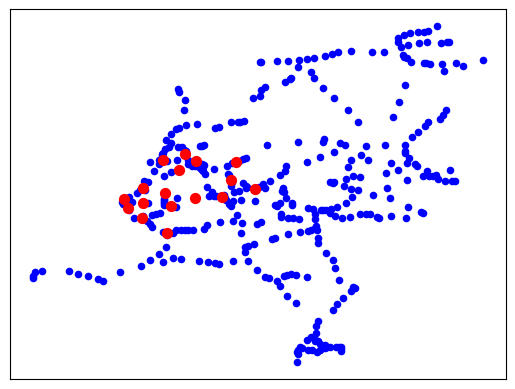

In [18]:
pos = {
    node: (data["lng"], data["lat"])
    for node, data in G.nodes(data=True)
}

red_nodes = [n for n in G.nodes() if G.nodes[n]["color"] == "red"]
blue_nodes = [n for n in G.nodes() if G.nodes[n]["color"] != "red"]

# draw blue first
nx.draw_networkx_nodes(
    G, pos,
    nodelist=blue_nodes,
    node_color="blue",
    node_size=20
)

# draw red on top
nx.draw_networkx_nodes(
    G, pos,
    nodelist=red_nodes,
    node_color="red",
    node_size=50
)

In [19]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

In [20]:
edges_df = pd.read_csv("edges.csv")

for _, row in edges_df.iterrows():
    n1 = row["from"]
    n2 = row["to"]

    lat1, lon1 = G.nodes[n1]["lat"], G.nodes[n1]["lng"]
    lat2, lon2 = G.nodes[n2]["lat"], G.nodes[n2]["lng"]

    dist = haversine(lat1, lon1, lat2, lon2)

    G.add_edge(n1, n2, weight=dist)

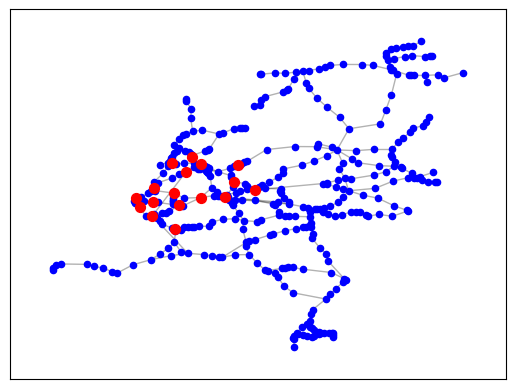

In [21]:
# edges
nx.draw_networkx_edges(G, pos, alpha=0.3)

# nodes (layered)
nx.draw_networkx_nodes(G, pos, nodelist=blue_nodes, node_color="blue", node_size=20)
nx.draw_networkx_nodes(G, pos, nodelist=red_nodes, node_color="red", node_size=50)

In [22]:
# all red cities
red_nodes = [n for n in G.nodes() if G.nodes[n]["color"] == "red"]

results = []

for source, target in itertools.combinations(red_nodes, 2):
    try:
        path = nx.shortest_path(G, source=source, target=target, weight="weight")
        distance = nx.shortest_path_length(G, source=source, target=target, weight="weight")

        results.append({
            "from": source,
            "to": target,
            "distance_km": distance,
            "path": path
        })
    except nx.NetworkXNoPath:
        results.append({
            "from": source,
            "to": target,
            "distance_km": None,
            "path": None
        })

shortest_paths_df = pd.DataFrame(results)

In [23]:
print(shortest_paths_df)

    from   to  distance_km                                               path
0    ALM  APN    43.053440  [ALM, ALMM, AMPO, NDB, BSMZ, HVSM, HVS, HVSP, ...
1    ALM  AMF    19.382959  [ALM, ALMM, AMPO, NDB, BSMZ, HVSM, HVS, BRN, AMF]
2    ALM  ASD    21.561287        [ALM, ALMM, AMPO, WP, DMN, ASSP, ASDM, ASD]
3    ALM   DT    58.697908  [ALM, ALMM, AMPO, WP, DMN, ASSP, ASDM, ASD, SH...
4    ALM  GVC    60.727389  [ALM, ALMM, AMPO, WP, DMN, ASSP, ASDM, ASD, AS...
..   ...  ...          ...                                                ...
131   UT   ZD    22.032106  [UT, UTZL, MAS, BKL, AC, ASHD, ASB, DVD, ASA, ...
132   UT  ZTM    43.276381  [UT, UTZL, MAS, BKL, WD, GDG, GD, LLZM, ZTMO, ...
133   WD   ZD    20.483704  [WD, BKL, AC, ASHD, ASB, DVD, ASA, ASDM, ASD, ...
134   WD  ZTM    28.482377                     [WD, GDG, GD, LLZM, ZTMO, ZTM]
135   ZD  ZTM    45.151800  [ZD, KZ, ZZS, WM, KMA, UTG, HK, BV, DRH, SPTN,...

[136 rows x 4 columns]


In [24]:
red_set = set(red_nodes)

direct_connections = []

for _, row in shortest_paths_df.iterrows():
    path = row["path"]
    
    if path is None:
        continue

    # only check intermediate nodes, not start/end
    intermediate_nodes = path[1:-1]

    # keep only if all intermediate nodes are blue
    if all(node not in red_set for node in intermediate_nodes):
        direct_connections.append({
            "from": row["from"],
            "to": row["to"],
            "distance_km": row["distance_km"],
            "path": path
        })

red_city_connections_df = pd.DataFrame(direct_connections)



In [25]:
print(red_city_connections_df[10:])

    from    to  distance_km                                               path
10   ASD    UT    16.148262  [ASD, ASDM, ASA, DVD, ASB, ASHD, AC, BKL, MAS,...
11   ASD    WD    14.599860      [ASD, ASDM, ASA, DVD, ASB, ASHD, AC, BKL, WD]
12   ASD    ZD     5.883844                                     [ASD, ASS, ZD]
13    DT   GVC     4.392149                           [DT, RSW, GVMW, GV, GVC]
14    DT  LEDN    15.090887     [DT, RSW, GVMW, GV, LAA, GVM, VST, DVNK, LEDN]
15    DT   RTD     7.715420                               [DT, DTCP, SDM, RTD]
16   GVC  LEDN    10.699713                   [GVC, LAA, GVM, VST, DVNK, LEDN]
17   GVC   ZTM    10.407587                                [GVC, VB, YPB, ZTM]
18   DDR   RTD    13.699285                [DDR, ZWD, BRD, RLB, RTZ, RTB, RTD]
19   DDR    UT    52.440528  [DDR, DDRS, SDTB, SDT, HBZM, GND, BHDV, GR, AK...
20    GD   RTD    16.139887                      [GD, NWK, CPS, RTA, RTN, RTD]
21    GD    WD    12.938336                         

{'ALM': Text(5.21764, 52.37503, 'ALM'),
 'APN': Text(4.6577777862549, 52.124443054199, 'APN'),
 'AMF': Text(5.3705554008484, 52.153888702393, 'AMF'),
 'ASD': Text(4.9002776145935, 52.378887176514, 'ASD'),
 'DT': Text(4.3563890457153, 52.00666809082, 'DT'),
 'GVC': Text(4.3249998092651, 52.080276489258, 'GVC'),
 'DDR': Text(4.668333530426, 51.807220458984, 'DDR'),
 'GD': Text(4.7044444084167, 52.017501831055, 'GD'),
 'HLM': Text(4.6383333206177, 52.38777923584, 'HLM'),
 'HVS': Text(5.1819443702698, 52.225833892822, 'HVS'),
 'LEDN': Text(4.4816665649414, 52.166110992432, 'LEDN'),
 'RTD': Text(4.468888759613, 51.92499923706, 'RTD'),
 'SHL': Text(4.7619442939758, 52.30944442749, 'SHL'),
 'UT': Text(5.1102776527405, 52.088890075684, 'UT'),
 'WD': Text(4.8936109542847, 52.084999084473, 'WD'),
 'ZD': Text(4.8136110305786, 52.438888549805, 'ZD'),
 'ZTM': Text(4.4772224426269, 52.047500610352, 'ZTM')}

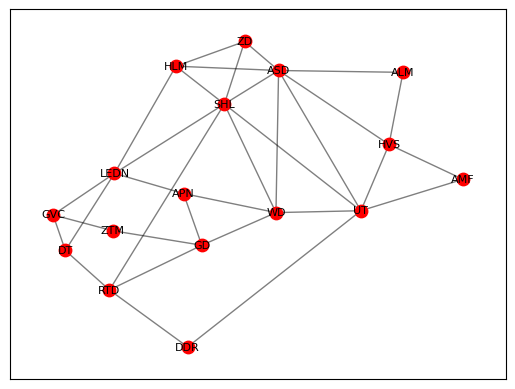

In [26]:
# create reduced graph with only red cities
G_red = nx.Graph()

# add red city nodes with original attributes
for node, data in G.nodes(data=True):
    if data.get("color") == "red":
        G_red.add_node(node, **data)

# add only the filtered red-red connections
for _, row in red_city_connections_df.iterrows():
    G_red.add_edge(
        row["from"],
        row["to"],
        weight=row["distance_km"]
    )

# positions from lat/lon
pos_red = {
    node: (data["lng"], data["lat"])
    for node, data in G_red.nodes(data=True)
}


nx.draw_networkx_edges(G_red, pos_red, alpha=0.5)
nx.draw_networkx_nodes(G_red, pos_red, node_color="red", node_size=80)
nx.draw_networkx_labels(G_red, pos_red, font_size=8)

In [ ]:
last_cities = pd.read_csv("last_cities.csv")

for _, row in last_cities.iterrows():
    node_name = row["name"]
    lat = row["lat"]
    lng = row["lng"]

    # add node
    G_red.add_node(
        node_name,
        station=row["station"],
        lat=lat,
        lng=lng,
        color="red"
    )

    # distance to RTD with bus penalty
    lat_rtd = G_red.nodes["RTD"]["lat"]
    lng_rtd = G_red.nodes["RTD"]["lng"]

    weight = 2 * haversine(lat, lng, lat_rtd, lng_rtd)

    # add edge to RTD
    G_red.add_edge(node_name, "RTD", weight=weight, mode="bus")

In [28]:
print(G_red.nodes(data=True))

[('ALM', {'station': 'Almere Centrum', 'lat': 52.37503, 'lng': 5.21764, 'color': 'red'}), ('APN', {'station': 'Alphen a/d Rijn', 'lat': 52.124443054199, 'lng': 4.6577777862549, 'color': 'red'}), ('AMF', {'station': 'Amersfoort Centraal', 'lat': 52.153888702393, 'lng': 5.3705554008484, 'color': 'red'}), ('ASD', {'station': 'Amsterdam Centraal', 'lat': 52.378887176514, 'lng': 4.9002776145935, 'color': 'red'}), ('DT', {'station': 'Delft', 'lat': 52.00666809082, 'lng': 4.3563890457153, 'color': 'red'}), ('GVC', {'station': 'Den Haag Centraal', 'lat': 52.080276489258, 'lng': 4.3249998092651, 'color': 'red'}), ('DDR', {'station': 'Dordrecht', 'lat': 51.807220458984, 'lng': 4.668333530426, 'color': 'red'}), ('GD', {'station': 'Gouda', 'lat': 52.017501831055, 'lng': 4.7044444084167, 'color': 'red'}), ('HLM', {'station': 'Haarlem', 'lat': 52.38777923584, 'lng': 4.6383333206177, 'color': 'red'}), ('HVS', {'station': 'Hilversum', 'lat': 52.225833892822, 'lng': 5.1819443702698, 'color': 'red'}), (

{('ALM', 'ASD'): Text(5.058955826358254, 52.37695862448691, '21.6'),
 ('ALM', 'HVS'): Text(5.199792192648077, 52.30043197781365, '6.5'),
 ('APN', 'GD'): Text(4.6811123856268795, 52.0709694903794, '4.9'),
 ('APN', 'LEDN'): Text(4.569721598588609, 52.14527715983605, '12.0'),
 ('APN', 'WD'): Text(4.775692401555762, 52.104721398610714, '16.1'),
 ('AMF', 'HVS'): Text(5.276249925257742, 52.18986128246457, '12.9'),
 ('AMF', 'UT'): Text(5.2404221683500225, 52.12139079789258, '17.8'),
 ('ASD', 'HLM'): Text(4.769305303790063, 52.383333211737956, '17.8'),
 ('ASD', 'HVS'): Text(5.041114211261212, 52.30235878560667, '19.2'),
 ('ASD', 'SHL'): Text(4.831104952473106, 52.34416278911769, '9.4'),
 ('ASD', 'UT'): Text(5.005278100217785, 52.23388798182115, '16.1'),
 ('ASD', 'WD'): Text(4.896944322378041, 52.23194480296556, '14.6'),
 ('ASD', 'ZD'): Text(4.856943974222069, 52.40888810434032, '5.9'),
 ('DT', 'GVC'): Text(4.340694420240291, 52.04347230704019, '4.4'),
 ('DT', 'LEDN'): Text(4.419029567860834, 5

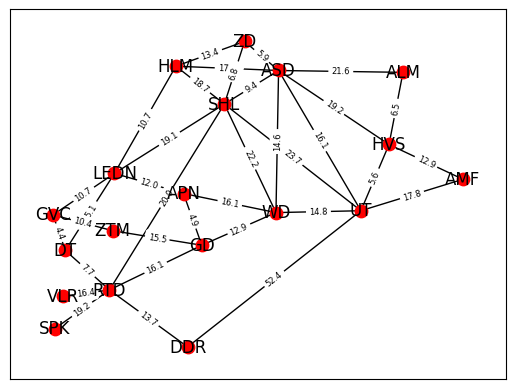

In [35]:
pos_red = {
    node: (data["lng"], data["lat"])
    for node, data in G_red.nodes(data=True)
}

nx.draw_networkx(G_red, pos_red, with_labels=True, node_color="red", node_size=80)

# add edge weights (rounded)
edge_labels = {
    (u, v): f"{data['weight']:.1f}"
    for u, v, data in G_red.edges(data=True)
}

nx.draw_networkx_edge_labels(G_red, pos_red, edge_labels=edge_labels, font_size=6)